# Adult dataset operating modes with ResNet encoder

This notebook demonstrates MIMIC's main operating modes on the Adult/Census Income dataset using the PyTorch ResNet encoder.

Set `N_ROWS` to control the working sample size. The default is intentionally small enough for quick experimentation.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, mean_absolute_error

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mimic import MIMIC
from mimic.diagnostics import binary_classification_diagnostics, categorical_feature_plot, categorical_feature_report, classical_mds_2d, pairwise_feature_plot
from mimic_notebook_utils import plot_binary_classification_curves, plot_feature_embedding_grid, plot_global_embedding_color_grid, plot_pareto_feature_pairs

RANDOM_STATE = 42
N_ROWS = 200
rng = np.random.default_rng(RANDOM_STATE)


## Load and clean Adult

Adult has no real ID column, but it does contain sampling-weight and education-code columns that are not useful for this demonstration. `fnlwgt` has a very wide range and `education-num` duplicates information already present in `education`, so both are excluded.

In [2]:
adult = fetch_openml("adult", version=2, as_frame=True)
raw = adult.frame.copy()
raw = raw.replace("?", np.nan)

drop_columns = ["fnlwgt", "education-num"]
clean = raw.drop(columns=drop_columns).dropna().reset_index(drop=True)
clean["income"] = clean["class"].astype(str)
clean = clean.drop(columns=["class"])

sampled = clean.sample(n=2 * N_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
df = sampled.iloc[:N_ROWS].reset_index(drop=True)
test_df = sampled.iloc[N_ROWS:].reset_index(drop=True)

regression_columns = ["age", "hours-per-week", "capital-gain", "capital-loss"]
classification_columns = [c for c in df.columns if c not in regression_columns]

dataset_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(df), len(test_df)],
        "columns": [df.shape[1], test_df.shape[1]],
        "income_<=50K": [
            df["income"].value_counts(normalize=True).get("<=50K", 0.0),
            test_df["income"].value_counts(normalize=True).get("<=50K", 0.0),
        ],
        "income_>50K": [
            df["income"].value_counts(normalize=True).get(">50K", 0.0),
            test_df["income"].value_counts(normalize=True).get(">50K", 0.0),
        ],
    }
)

display(dataset_summary.style.format({"income_<=50K": "{:.1%}", "income_>50K": "{:.1%}"}))
display(df.head())

,split,rows,columns,income_<=50K,income_>50K
0,train,200,13,73.0%,27.0%
1,test,200,13,73.5%,26.5%


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,19,Self-emp-not-inc,10th,Married-spouse-absent,Adm-clerical,Unmarried,Amer-Indian-Eskimo,Female,0,0,40,United-States,<=50K
1,45,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
2,47,Private,Assoc-voc,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
3,23,Private,Some-college,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,United-States,<=50K
4,53,Local-gov,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K


## Fit from clean data

The model is fitted on clean complete rows using a ResNet encoder. Later cells create perturbed copies to test each operating mode.

In [3]:
mimic = MIMIC(
    columns={"regression": regression_columns, "classification": classification_columns},
    mode="factorised", # modes: "identity", "direct", "factorised", "joint"
    capacity=0.3,
    random_state=RANDOM_STATE,
    verbose=True,
)
mimic.fit(df)
embedding = mimic.transform(df)
fit_summary = pd.DataFrame(
    {
        "quantity": ["training_rows", "embedding_rows", "embedding_dimensions", "modelled_columns"],
        "value": [len(df), embedding.shape[0], embedding.shape[1], len(regression_columns) + len(classification_columns)],
    }
)
display(fit_summary)

MIMIC init hyperparameters:
  capacity: 0.3
  columns:
    regression:
      - age
      - hours-per-week
      - capital-gain
      - capital-loss
    classification:
      - workclass
      - education
      - marital-status
      - occupation
      - relationship
      - race
      - sex
      - native-country
      - income
  decoder: None
  encoder: None
  generation_decode_mode: factorised
  level: None
  mode: factorised
  n_bootstrap: None
  n_jobs: None
  policy: None
  random_state: 42
  verbose: True
MIMIC resolved fit configuration:
  mode_: factorised
  level_: 2
  capacity_: 0.3
  n_bootstrap_: 2
  generation_decode_mode_config_: factorised
  encoder_:
    class: ResNetEncoder
    parameters:
      batch_size: 99
      device: auto
      dropout: 0.06
      embedding_dim: 39
      hidden_dim: 44
      learning_rate: 0.0015035617008818166
      max_epochs: 97
      n_layers: 3
      patience: 10
      random_state: 42
      restore_best_checkpoint: True
      task: regress

KeyboardInterrupt: 

## 1. Missing-value imputation

Hide known values and measure how well MIMIC reconstructs them.

In [ ]:
impute_columns = ["age", "hours-per-week", "workclass", "marital-status"]
masked = test_df.copy()
truth = []
for col in impute_columns:
    rows = rng.choice(masked.index, size=max(20, N_ROWS // 20), replace=False)
    truth.append(pd.DataFrame({"row": rows, "column": col, "true": test_df.loc[rows, col].to_numpy()}))
    masked.loc[rows, col] = np.nan
truth = pd.concat(truth, ignore_index=True)

reconstructed = mimic.impute(masked, columns=impute_columns)
truth["predicted"] = [reconstructed.loc[r, c] for r, c in zip(truth["row"], truth["column"])]

imputation_scores = []
for col in impute_columns:
    part = truth[truth["column"] == col]
    if col in regression_columns:
        score = mean_absolute_error(part["true"].astype(float), part["predicted"].astype(float))
        metric = "MAE"
    else:
        score = accuracy_score(part["true"].astype(str), part["predicted"].astype(str))
        metric = "accuracy"
    imputation_scores.append({"column": col, "metric": metric, "score": score})

imputation_scores = pd.DataFrame(imputation_scores)
imputation_examples = truth.head(12)
display(imputation_scores.style.format({"score": "{:.3f}"}))
display(imputation_examples)

,column,metric,score
0,age,MAE,8.639
1,hours-per-week,MAE,8.250
2,workclass,accuracy,0.710
3,marital-status,accuracy,0.790


,row,column,true,predicted
0,866,age,25,25.988533
1,1862,age,32,27.230126
2,1326,age,36,41.607028
3,911,age,39,39.568722
4,869,age,32,42.190663
5,1517,age,54,46.432827
6,302,age,53,59.323253
7,640,age,45,31.231725
8,320,age,32,29.732164
9,1373,age,21,41.4333


## 2. Data inconsistency check

Inject unrealistic numerical values beyond two standard deviations from the clean distribution and rank entries by prediction discrepancy.

In [ ]:
corrupted = test_df.copy()
for col in ["age", "hours-per-week"]:
    corrupted[col] = corrupted[col].astype(float)

corruption_records = []
for col in ["age", "hours-per-week"]:
    rows = rng.choice(corrupted.index, size=max(10, N_ROWS // 50), replace=False)
    mu = test_df[col].mean()
    sigma = test_df[col].std()
    corrupted.loc[rows, col] = mu + 4 * sigma
    corruption_records.extend({"row_index": r, "column": col} for r in rows)
corruption_records = pd.DataFrame(corruption_records)

diagnostics = mimic.confidence(corrupted, columns=["age", "hours-per-week"])
merged_marker = diagnostics.merge(
    corruption_records.assign(was_corrupted=True),
    on=["row_index", "column"],
    how="left",
)["was_corrupted"]
diagnostics["was_corrupted"] = (merged_marker == True).to_numpy()

ranked = diagnostics.sort_values("discrepancy", ascending=False)
top_k = len(corruption_records)
precision_at_k = ranked.head(top_k)["was_corrupted"].mean()

inconsistency_summary = pd.DataFrame(
    {"metric": ["corrupted_entries", "precision_at_k"], "value": [top_k, precision_at_k]}
)
inconsistency_top = ranked[["row_index", "column", "observed", "prediction", "discrepancy", "was_corrupted"]].head(12)
display(inconsistency_summary.style.format({"value": "{:.3f}"}))
display(inconsistency_top.style.format({"observed": "{:.2f}", "prediction": "{:.2f}", "discrepancy": "{:.2f}"}))

,metric,value
0,corrupted_entries,80.000
1,precision_at_k,0.800


,row_index,column,observed,prediction,discrepancy,was_corrupted
85,85,age,91.35,19.56,71.80,True
47,47,age,91.35,21.68,69.67,True
1553,1553,age,91.35,22.03,69.33,True
1807,1807,age,91.35,22.05,69.30,True
1720,1720,age,91.35,23.13,68.22,True
2332,332,hours-per-week,98.00,31.29,66.71,False
2601,601,hours-per-week,99.00,32.54,66.46,False
619,619,age,91.35,24.90,66.45,True
1292,1292,age,91.35,25.89,65.46,True
2989,989,hours-per-week,88.58,23.17,65.42,True


## 3. Supervised learning on income

Income prediction is represented as imputing a missing `income` target column.

,metric,value
0,accuracy,0.848
1,macro_f1,0.773
2,roc_auc,0.886
3,average_precision,0.709


,true_income,predicted_income
0,<=50K,<=50K
1,<=50K,<=50K
2,<=50K,<=50K
3,<=50K,<=50K
4,>50K,>50K
5,>50K,>50K
6,<=50K,<=50K
7,>50K,>50K
8,>50K,>50K
9,>50K,>50K


,prediction,confidence,entropy,probability_margin,vote_fraction
0,<=50K,1.000,0.000,1.000,1.000
1,<=50K,0.544,0.689,0.087,0.500
2,<=50K,1.000,0.001,1.000,1.000
3,<=50K,0.999,0.005,0.999,1.000
4,>50K,0.997,0.018,0.995,1.000
5,>50K,0.968,0.142,0.936,1.000
6,<=50K,1.000,0.003,0.999,1.000
7,>50K,0.924,0.268,0.849,1.000
8,>50K,0.985,0.078,0.970,1.000
9,>50K,0.979,0.102,0.958,1.000


predicted,<=50K,>50K
actual,,
<=50K,1420,133
>50K,172,275


predicted,<=50K,>50K
actual,,
<=50K,71.0%,6.7%
>50K,8.6%,13.8%


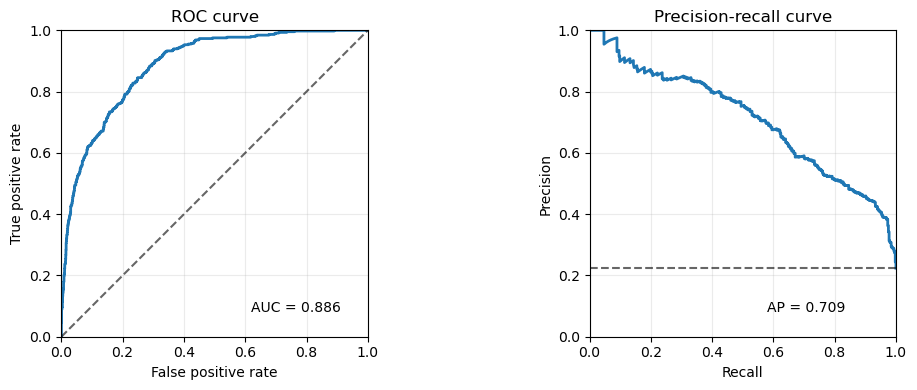

In [ ]:
income_task = test_df.copy()
income_truth = test_df["income"].copy()
income_task["income"] = np.nan

income_pred = mimic.impute(income_task, columns=["income"])
y_true = income_truth.astype(str)
y_pred = income_pred["income"].astype(str)
income_confidence = mimic.confidence(income_task, columns=["income"])

income_diagnostics = binary_classification_diagnostics(
    y_true,
    y_pred,
    income_confidence,
    positive_label=">50K",
    negative_label="<=50K",
)
income_examples = pd.DataFrame(
    {"true_income": y_true.head(12).to_numpy(), "predicted_income": y_pred.head(12).to_numpy()}
)

display(income_diagnostics.metrics.style.format({"value": "{:.3f}"}))
display(income_examples)
display(
    income_confidence[["prediction", "confidence", "entropy", "probability_margin", "vote_fraction"]]
    .head(12)
    .style.format(
        {
            "confidence": "{:.3f}",
            "entropy": "{:.3f}",
            "probability_margin": "{:.3f}",
            "vote_fraction": "{:.3f}",
        }
    )
)

fig, axes = plot_binary_classification_curves(income_diagnostics)

display(income_diagnostics.confusion_counts.style.set_caption("Confusion table: absolute counts"))
display(
    income_diagnostics.confusion_relative.style
    .format("{:.1%}")
    .set_caption("Confusion table: relative counts")
)


## 4. Synthetic generation

Generate synthetic rows, inspect traceability, and compare original and generated distributions in a shared 2D projection.

In [ ]:
synthetic, trace = mimic.sample(len(test_df), return_trace=True)

display(test_df.head(12).style.set_caption("Held-out test rows"))
display(synthetic.head(12).style.set_caption("Displacement-generated rows"))
display(trace.head(12).style.set_caption("Generation trace"))


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,43,Private,5th-6th,Never-married,Machine-op-inspct,Unmarried,White,Female,0,0,40,Mexico,<=50K
1,61,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,56,United-States,<=50K
2,34,Private,9th,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,36,Private,Assoc-voc,Divorced,Tech-support,Unmarried,White,Female,0,0,40,United-States,<=50K
4,58,Self-emp-not-inc,Doctorate,Married-civ-spouse,Prof-specialty,Husband,White,Male,15024,0,32,United-States,>50K
5,38,Private,Bachelors,Married-civ-spouse,Sales,Husband,White,Male,0,0,42,United-States,>50K
6,48,Private,Some-college,Never-married,Exec-managerial,Not-in-family,Black,Female,0,0,40,United-States,<=50K
7,49,Private,Prof-school,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,>50K
8,43,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K
9,52,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,43,Private,7th-8th,Divorced,Craft-repair,Not-in-family,White,Male,9,0,40,United-States,<=50K
1,41,Private,HS-grad,Married-civ-spouse,Other-service,Husband,White,Male,12,-1,40,United-States,<=50K
2,32,Private,Assoc-acdm,Divorced,Exec-managerial,Own-child,White,Female,-48,1,43,United-States,<=50K
3,25,Private,HS-grad,Never-married,Other-service,Own-child,White,Male,2,-1,40,United-States,<=50K
4,19,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,-1,-2,40,United-States,<=50K
5,62,Self-emp-not-inc,12th,Married-civ-spouse,Transport-moving,Husband,White,Male,-6,0,49,United-States,<=50K
6,22,Private,HS-grad,Never-married,Handlers-cleaners,Not-in-family,White,Male,-16,-2,40,United-States,<=50K
7,20,Private,5th-6th,Never-married,Farming-fishing,Not-in-family,White,Male,44,0,48,Mexico,<=50K
8,42,State-gov,Prof-school,Married-civ-spouse,Prof-specialty,Wife,White,Female,19293,2,40,United-States,>50K
9,46,Private,HS-grad,Divorced,Adm-clerical,Not-in-family,White,Female,5,-3,40,United-States,<=50K


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,generation_decode_mode,resolved_generation_decode_mode,random_state,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,component_index,component_probability,component_mean,component_sigma,sample_log_probability,sampled_class_code,class_probabilities
0,embedding,0,displacement,178.000000,1838.000000,159.000000,0.469439,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,embedding,1,displacement,866.000000,1312.000000,1683.000000,0.598684,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,embedding,2,displacement,188.000000,1951.000000,104.000000,0.630570,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,embedding,3,displacement,1434.000000,1671.000000,1259.000000,0.314057,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,embedding,4,displacement,900.000000,1663.000000,900.000000,0.713382,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
5,embedding,5,displacement,741.000000,1637.000000,741.000000,0.571933,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
6,embedding,6,displacement,1645.000000,419.000000,1360.000000,0.363619,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
7,embedding,7,displacement,184.000000,816.000000,184.000000,0.281909,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
8,embedding,8,displacement,1655.000000,818.000000,1090.000000,0.629044,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
9,embedding,9,displacement,1401.000000,777.000000,1401.000000,0.735349,mutual,basic,None,NeuralConditionalSampler,auto,factorised,42.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


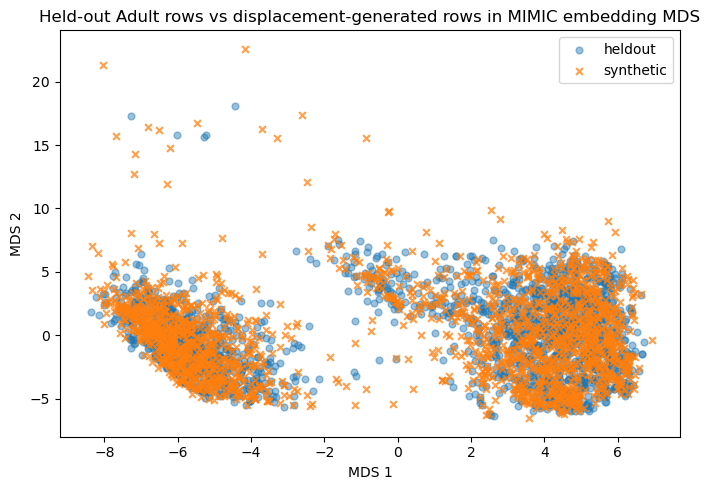

In [ ]:
combined = pd.concat(
    [test_df.assign(source="heldout"), synthetic.assign(source="synthetic")],
    ignore_index=True,
)

# Use MIMIC's fitted embedding for both original and generated rows, then project jointly with classical MDS.
H_combined = mimic.transform(combined.drop(columns=["source"]))
plot_df = classical_mds_2d(H_combined, random_state=RANDOM_STATE)
plot_df["source"] = combined["source"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 5))
for source, marker, alpha in [("heldout", "o", 0.45), ("synthetic", "x", 0.75)]:
    part = plot_df[plot_df["source"] == source]
    ax.scatter(part["mds1"], part["mds2"], label=source, marker=marker, alpha=alpha, s=24)
ax.set_title("Held-out Adult rows vs displacement-generated rows in MIMIC embedding MDS")
ax.set_xlabel("MDS 1")
ax.set_ylabel("MDS 2")
ax.legend()
fig.tight_layout()

In [ ]:
summary = pd.concat(
    [test_df[regression_columns].describe().T.add_prefix("heldout_"), synthetic[regression_columns].describe().T.add_prefix("synthetic_")],
    axis=1,
)
comparison_summary = summary[["heldout_mean", "synthetic_mean", "heldout_std", "synthetic_std"]]
display(comparison_summary.style.format("{:.2f}"))

,heldout_mean,synthetic_mean,heldout_std,synthetic_std
age,38.32,38.42,13.26,12.94
hours-per-week,40.73,41.35,11.96,12.13
capital-gain,792.41,1242.05,5466.87,8955.43
capital-loss,72.94,73.08,365.69,396.10


Text(0.5, 1.02, 'Pairwise numeric feature statistics: held-out vs displacement-generated')

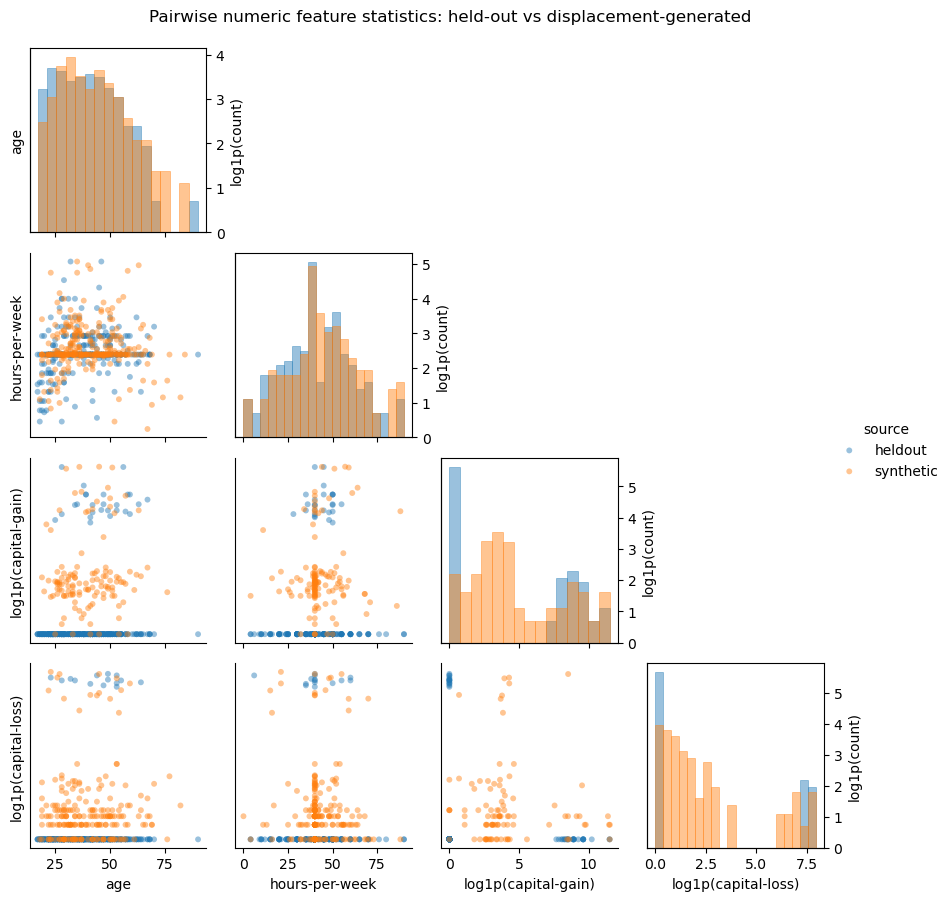

In [ ]:
pair_grid = pairwise_feature_plot(
    test_df,
    synthetic,
    features=regression_columns,
    log1p_features=["capital-gain", "capital-loss"],
    original_label="heldout",
    generated_label="synthetic",
    max_rows_per_source=300,
    random_state=RANDOM_STATE,
)
pair_grid.fig.suptitle("Pairwise numeric feature statistics: held-out vs displacement-generated", y=1.02)


### Categorical feature distributions


,feature,total_variation_distance,n_categories
3,occupation,0.067,14
1,education,0.051,16
8,income,0.051,2
6,sex,0.039,2
4,relationship,0.038,6
2,marital-status,0.029,7
7,native-country,0.024,38
0,workclass,0.014,6
5,race,0.011,5


,feature,category,heldout_proportion,synthetic_proportion,absolute_difference
6,education,Bachelors,15.6%,18.9%,3.3%
7,education,HS-grad,32.8%,30.6%,2.2%
8,education,Masters,5.7%,4.7%,1.0%
9,education,Prof-school,1.4%,1.9%,0.5%
10,education,Some-college,20.9%,20.4%,0.5%
11,education,12th,1.1%,1.6%,0.5%
43,income,>50K,22.4%,27.5%,5.1%
44,income,<=50K,77.6%,72.5%,5.1%
12,marital-status,Married-civ-spouse,44.8%,47.0%,2.3%
13,marital-status,Divorced,14.8%,12.8%,2.0%


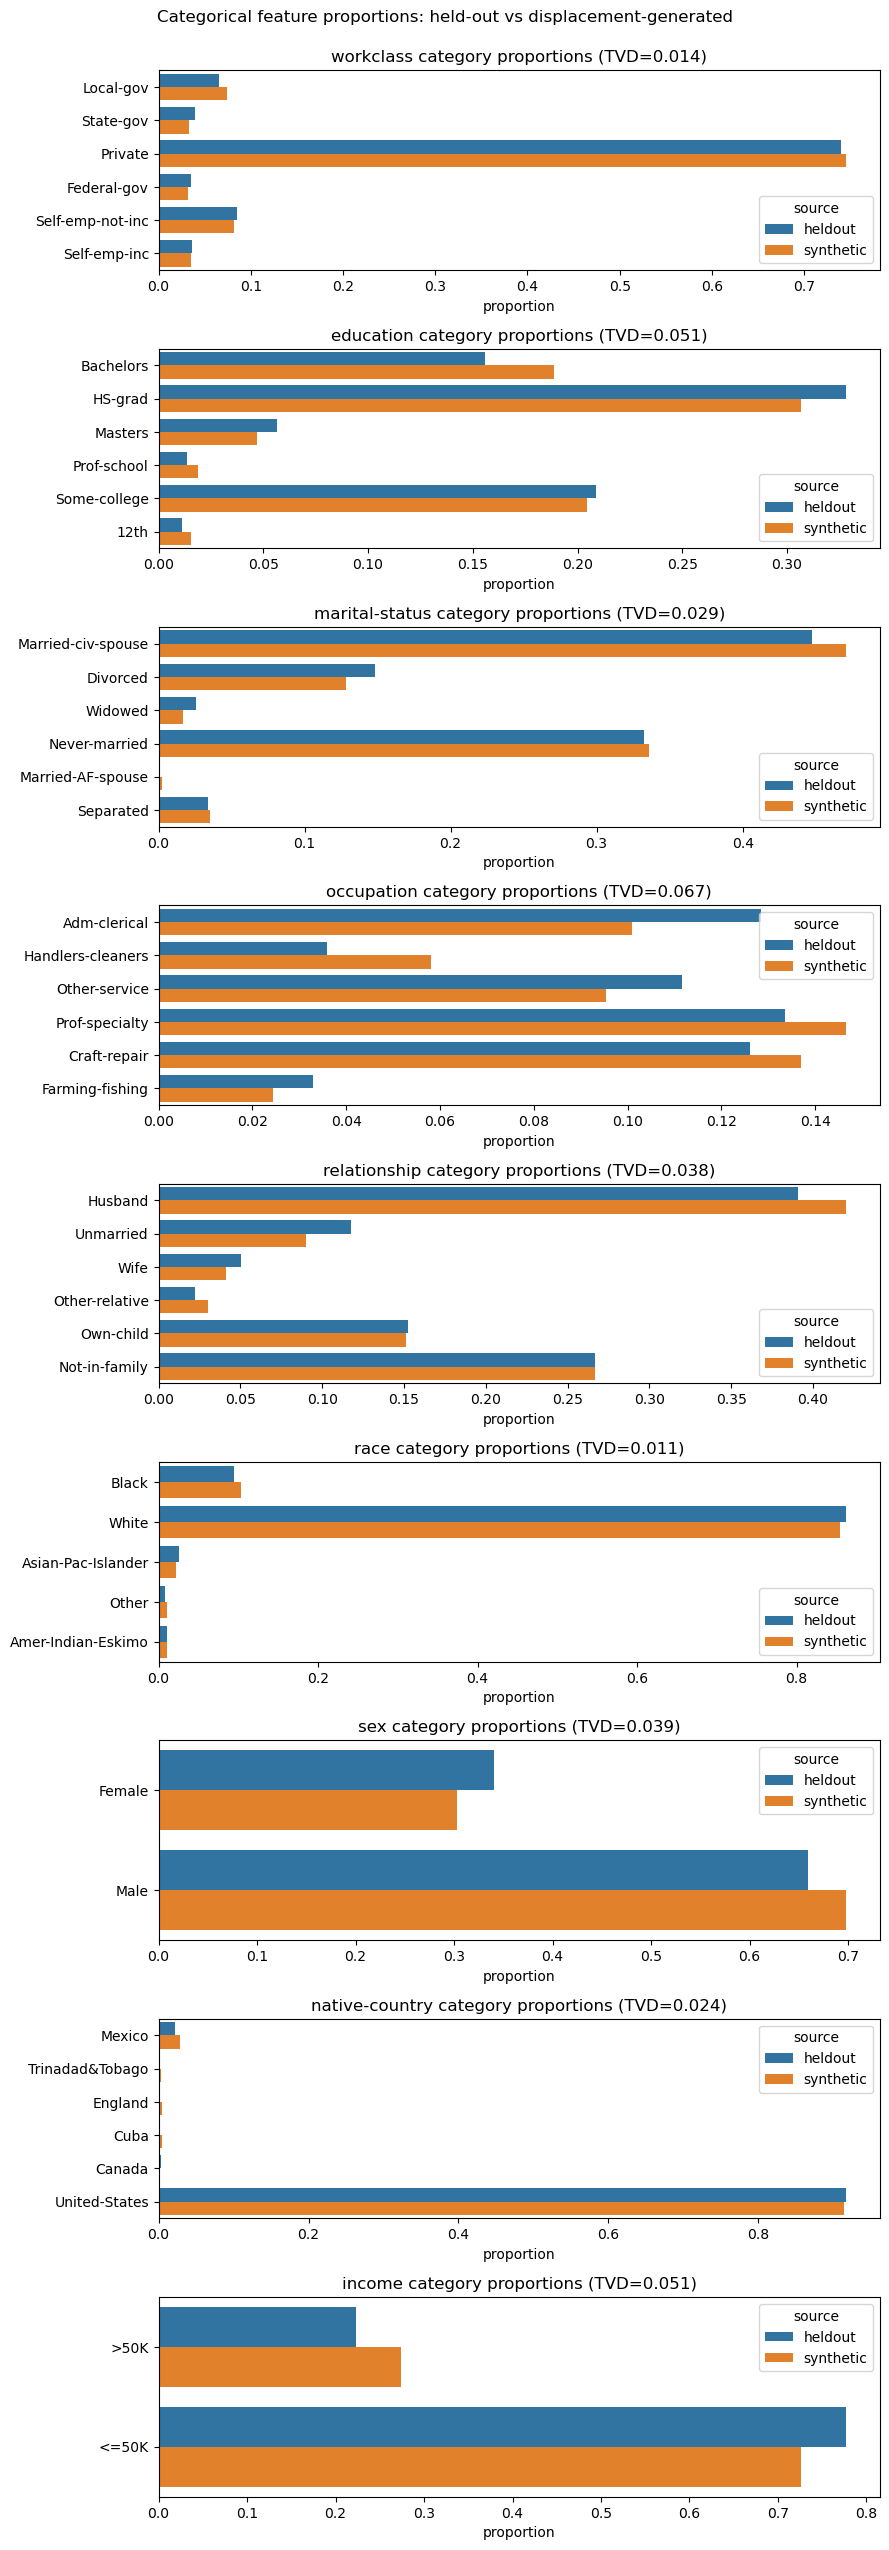

In [ ]:
categorical_fig, categorical_axes, categorical_report, categorical_summary = categorical_feature_plot(
    test_df,
    synthetic,
    features=classification_columns,
    original_label="heldout",
    generated_label="synthetic",
    top_n=6,
)
categorical_fig.suptitle("Categorical feature proportions: held-out vs displacement-generated", y=1.01)
display(
    categorical_summary.sort_values("total_variation_distance", ascending=False)
    .style.format({"total_variation_distance": "{:.3f}"})
)
display(
    categorical_report.sort_values(["feature", "absolute_difference"], ascending=[True, False])
    .style.format(
        {
            "heldout_proportion": "{:.1%}",
            "synthetic_proportion": "{:.1%}",
            "absolute_difference": "{:.1%}",
        }
    )
)


## 5. Feature-wise embedding projections

Each panel projects one feature-specific embedding block to 2D and colours rows by that same raw feature value.


Text(0.5, 1.01, 'Feature-wise MIMIC embeddings coloured by their own values')

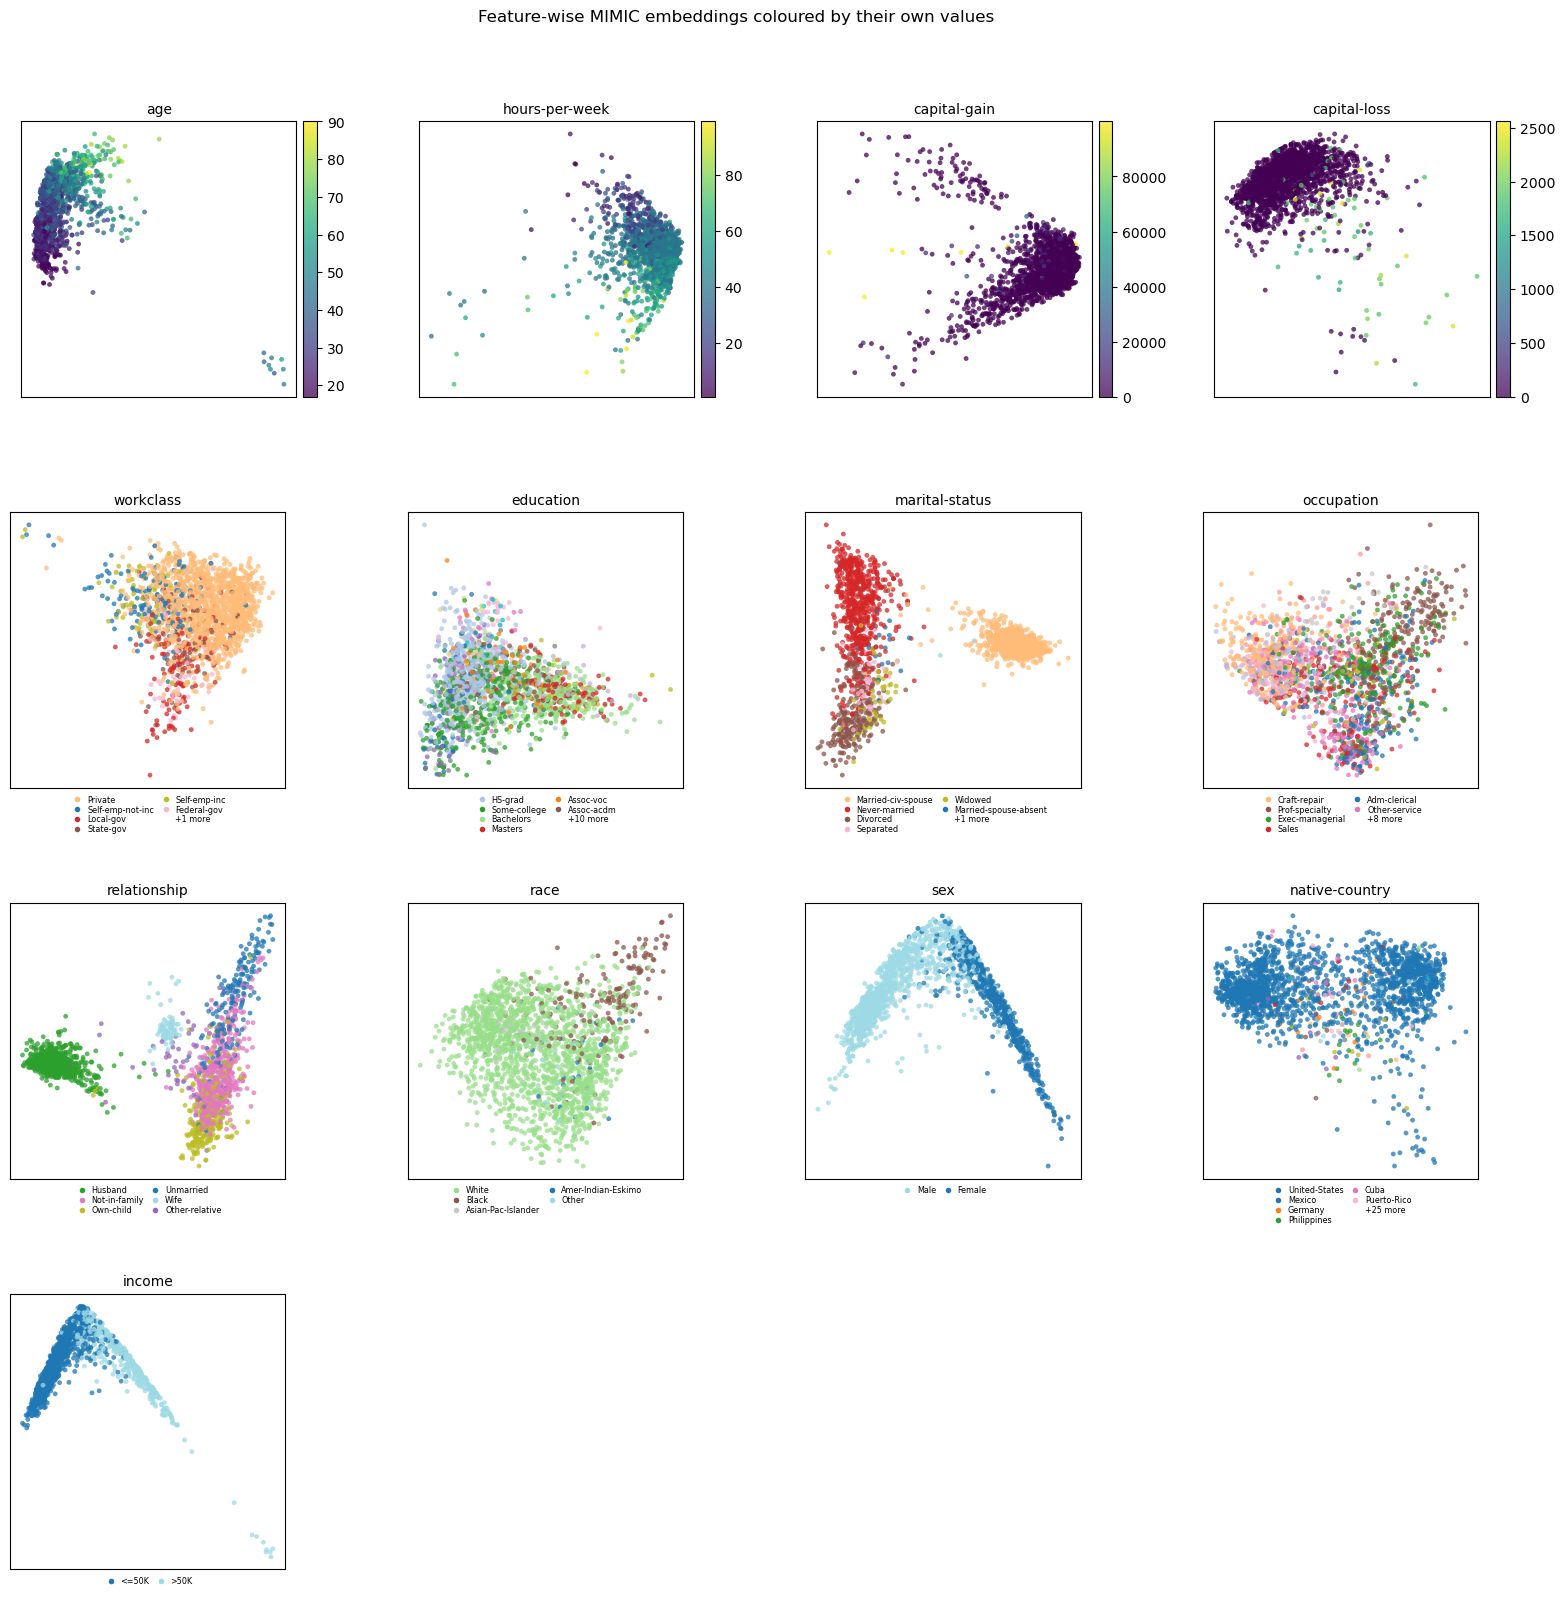

In [ ]:
feature_grid_fig, feature_grid_axes = plot_feature_embedding_grid(
    mimic,
    df,
    columns=regression_columns + classification_columns,
    n_cols=4,
    size=(4,4),
    random_state=RANDOM_STATE,
)
feature_grid_fig.suptitle("Feature-wise MIMIC embeddings coloured by their own values", y=1.01)


### Full embedding colored by each feature


Text(0.5, 1.01, 'Full MIMIC embedding coloured by each feature')

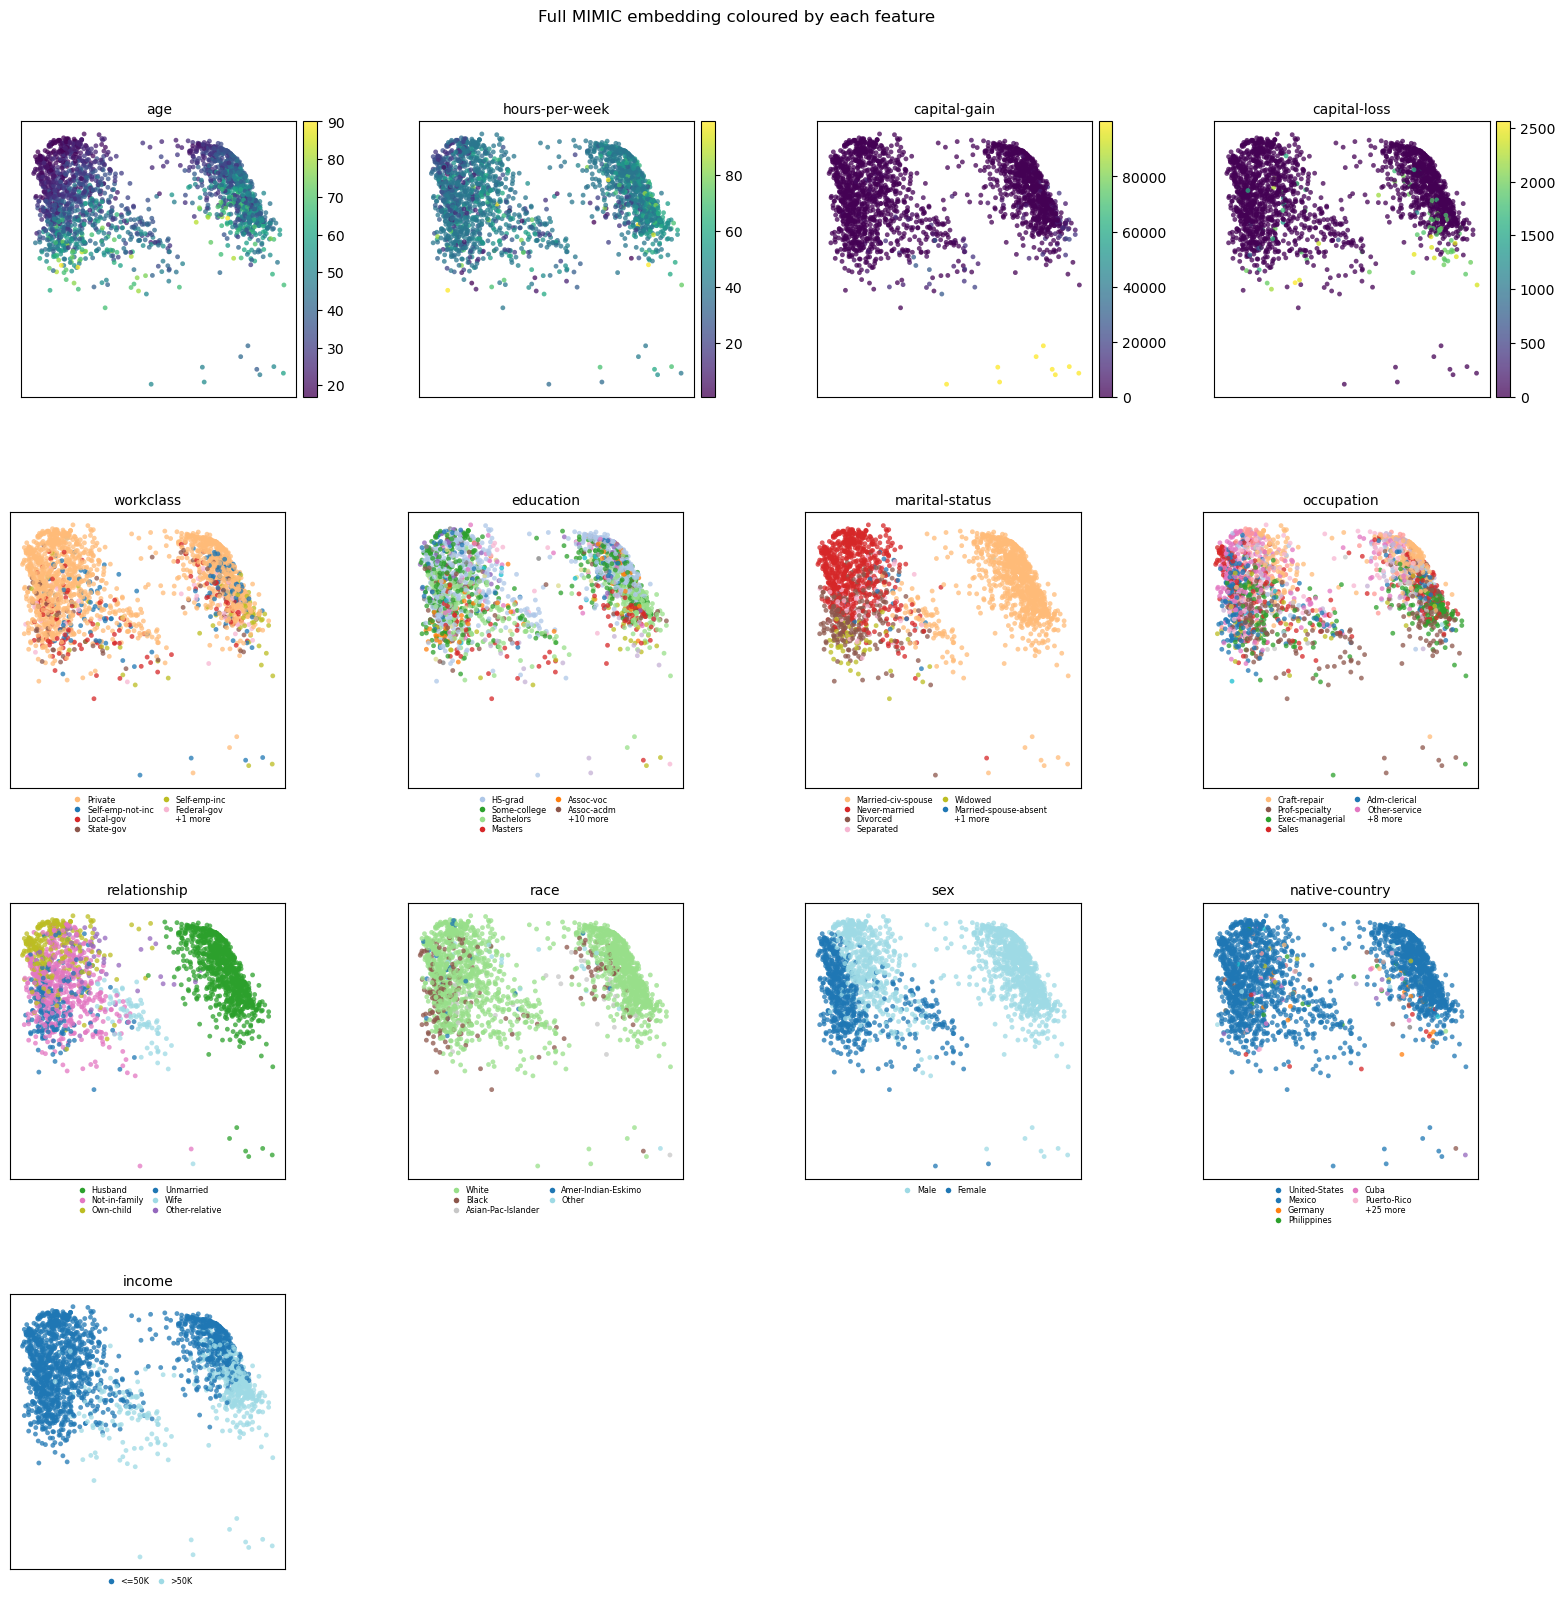

In [ ]:
global_grid_fig, global_grid_axes = plot_global_embedding_color_grid(
    mimic,
    df,
    columns=regression_columns + classification_columns,
    n_cols=4,
    size=(4, 4),
    random_state=RANDOM_STATE,
)
global_grid_fig.suptitle("Full MIMIC embedding coloured by each feature", y=1.01)


## 6. Pareto feature-pair views

Feature pairs are selected on two objectives: high average association with `income` and low association between the two features. Each Pareto-front pair is plotted in 2D and coloured by `income`.


,feature_x,feature_y,target_association,pair_association,pareto
0,marital-status,sex,0.571,0.454,True
1,age,sex,0.560,0.089,True
2,education,sex,0.397,0.089,True
3,capital-gain,sex,0.384,0.030,True
4,age,capital-loss,0.279,0.028,True
5,capital-gain,race,0.116,0.023,True


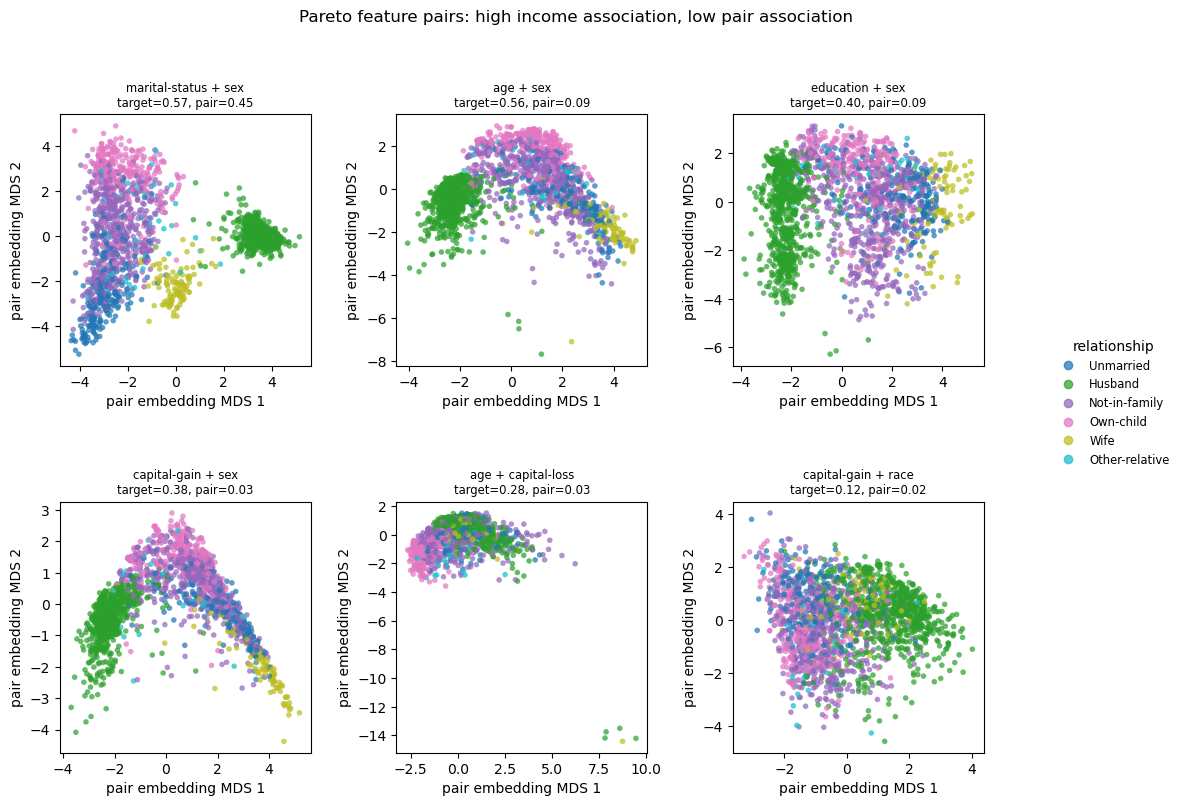

In [ ]:
pareto_fig, pareto_axes, pareto_pairs = plot_pareto_feature_pairs(
    mimic,
    test_df,
    target="relationship",
    columns=regression_columns + [c for c in classification_columns if c != "income"],
    max_pairs=6,
    size=(4,4),
)
pareto_fig.suptitle("Pareto feature pairs: high income association, low pair association", y=1.02)
display(
    pareto_pairs[pareto_pairs["pareto"]]
    .head(12)
    .style.format({"target_association": "{:.3f}", "pair_association": "{:.3f}"})
)
